This code is based off of the repository provided by the DESI collaboration: https://github.com/desihub/tutorials/blob/main/01_getting_started/06_PublicDatabaseAccess.ipynb

## Imports

In [16]:
import numpy as np                        # for math
import pandas as pd                       # for data manipulation
import matplotlib.pyplot as plt           # for plotting
import os                                 # for file paths

from dl import queryClient as qc          # for querying data
from sparcl.client import SparclClient    # ''
from tqdm import tqdm                     # displaying a progress bar
from astropy.convolution import convolve, Gaussian1DKernel  # for smoothing spectra

client = SparclClient()  # initialize SPARCL client for querying data

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


## DESI database tables

There are many tables within the `desi_dr1` database. Here, we list out these tables ...

In [4]:
print(qc.schema("desi_dr1"))  # display database table info


Schema: desi_dr1

      Table Name   Description
      ----------   -----------
          agngal   Value-Added Catalog of DESI DR1 galaxies and quasars with 
                   spectral and infrared classification diagnostics (17,995,5
                   99 rows)
           emfit   Emission-Line flux and width measurements for low-redshift
                   (z <= 0.45) sources in DR1 (7,378,347 rows)
        exposure   Summary quantities for every DESI exposure (9,176 rows)
     fiberassign   Quantities obtained when a DESI target is assigned to a fi
                   ber (25,061,082 rows)
           frame   Summary quantities for each petal of the DESI instrument i
                   n a given exposure; in normal operation there are ten fram
                   es for every exposure (269,960 rows)
             mws   Milky Way Survey Value-Added Catalog (6,372,607 rows)
      photometry   Photometric quantities from LS DR9 for every TARGETID (76,
                   001,458 rows)
    

We will focus on the `agngal` table within the `desi_dr1` database. This table contains ~18 million DESI DR1 galaxies and quasars with spectral and infrared classification diagnostics. Notice that one of the many spectral measurements is He II 4686 emission. 

In [5]:
print(qc.schema("desi_dr1.agngal"))  # display table column info


Schema: desi_dr1
 Table: agngal

     Column Name   Description
     -----------   -----------
               z   Redshift from the FastSpecFit catalog
            zerr   Redshift error
       target_ra   Right Ascension in decimal degrees (J2000)
      target_dec   Declination in decimal degrees (J2000)
         min_mjd   MJD of the first exposure in coadded spectrum
        mean_mjd   Mean of MJD of exposures in a coadded spectrum
         max_mjd   MJD of the last exposure in coadded spectrum
            elon   Ecliptic longitude
            elat   Ecliptic latitude
            glon   Galactic longitude
            glat   Galactic latitude
        targetid   Unique identifier for each object observed by DESI
           zwarn   Warning flags (0 is good)
           ls_id   Legacy Surveys DR9 identifier from RELEASE, OBJID, BRICKID
     desi_target   DESI (dark time program) target selection bitmask
     scnd_target   SCND (secondary program) target selection bitmask
      bgs_target 

## Querying DESI sources for VMS candidates

For this query, we require our sample to contain sources
- from the main survey which have primary coadded spectra
- classified as nearby galaxies
- with significant HE II 4686 emission

In [10]:
query = """
SELECT
    a.targetid,
    a.target_ra,
    a.target_dec,
    a.z,

    a.heii_4686_flux,
    a.heii_4686_flux_ivar,
    a.heii_4686_flux * SQRT(a.heii_4686_flux_ivar) AS heii_4686_snr,

    a.hbeta_flux,
    a.hbeta_flux_ivar,
    a.oiii_5007_flux,
    a.oiii_5007_flux_ivar,
    a.halpha_flux,
    a.halpha_flux_ivar,
    a.nii_6584_flux,
    a.nii_6584_flux_ivar,

    a.logmstar

FROM desi_dr1.agngal AS a

WHERE

    (a.survey='main') 
    AND a.main_primary
    AND (a.zwarn=0)

    AND (a.spectype='GALAXY')
    AND a.z < 0.45
    
    AND a.heii_4686_flux > 0
    AND a.heii_4686_flux_ivar > 0
    AND a.heii_4686_flux * SQRT(a.heii_4686_flux_ivar) > 5

ORDER BY heii_4686_snr DESC
"""

desi_sample = qc.query(sql=query, fmt="pandas")  # writing out the result of this query into a Pandas dataframe
desi_sample.head()

,targetid,target_ra,target_dec,z,heii_4686_flux,heii_4686_flux_ivar,heii_4686_snr,hbeta_flux,hbeta_flux_ivar,oiii_5007_flux,oiii_5007_flux_ivar,halpha_flux,halpha_flux_ivar,nii_6584_flux,nii_6584_flux_ivar,logmstar
0,2305843041057037638,272.089109,-1.142434,0.297237,19906.088,0.000091,189.979487,20443.2320,0.000088,19680.5000,0.000084,14039.785,0.000225,8259.75900,0.000345,12.824077
1,2305843041056850482,272.465992,-0.830448,0.372828,19731.775,0.000088,185.051404,21245.8480,0.000085,12967.2080,0.000082,25566.191,0.000075,6255.44500,0.000066,13.595987
2,2305843041057102923,273.423802,-1.186909,0.449643,7687.383,0.000486,169.515087,7890.9575,0.000479,7171.9946,0.000483,9511.127,0.000368,4988.64550,0.000336,13.509949
3,2305843041061401395,274.250058,-1.076078,0.449482,15221.553,0.000088,143.191032,15662.5660,0.000085,16290.9620,0.000075,19195.139,0.000071,18778.40400,0.000063,13.425317
4,2305843041056901022,272.316440,-1.850930,0.265760,9344.481,0.000106,96.355426,9478.1900,0.000103,7143.5420,0.000098,6164.432,0.000299,528.66327,0.000316,11.773345


In [ ]:
len(desi_sample)  # how many galaxies in our sample ?

3999

## Redshift distribution of VMS candidates

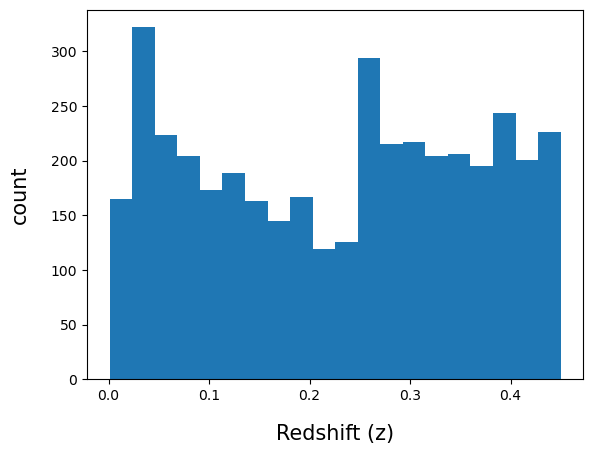

In [12]:
plt.figure()
plt.hist(desi_sample['z'], bins=20)
plt.xlabel('Redshift (z)', fontsize=15, labelpad=15)
plt.ylabel('count', fontsize=15, labelpad=15)
plt.show()

## Retrieve Spectra with SPARCL

Below, we loop through these VMS candidates and retrieve any available spectra using SPARCL. Depending on the sample size, this may take several minutes to run ...

In [13]:
targetids = desi_sample["targetid"].astype(int).unique().tolist()  # save all target ids to a list
batch_size = 100  # we will save spectra for our sample in batches to ensure the SPARCL server doesn't crash...

spectra_dict = {}

# loop through each galaxy in our sample
for i in tqdm(range(0, len(targetids), batch_size)):
    batch = targetids[i:i + batch_size]

    try:
        # retrieve spectral record
        res = client.retrieve_by_specid(
            specid_list=batch,
            dataset_list=["DESI-DR1"],
            include=[
                "specid",
                "targetid",
                "redshift",
                "wavelength",
                "flux",
                "ivar",
                "mask",
                "spectype",
                "specprimary",
                "survey",
                "program",
                "redshift_warning",
                ],
                )

        # loop through each spectral record and save data into a dictionary
        for rec in res.records:
            spectra_dict[int(rec.targetid)] = {
                "wavelength": rec.wavelength,
                "flux": rec.flux,
                "flux_ivar": rec.ivar,
            }
            
    except Exception as e:
        print(f"Batch {i} failed:", e)

100%|██████████| 40/40 [11:20<00:00, 17.02s/it]


In [ ]:
# add spectra to our sample dataframe
desi_sample["has_spectrum"] = desi_sample["targetid"].isin(spectra_dict.keys())
desi_sample["wavelength"] = desi_sample["targetid"].map(lambda tid: spectra_dict.get(int(tid), {}).get("wavelength"))
desi_sample["flux"] = desi_sample["targetid"].map(lambda tid: spectra_dict.get(int(tid), {}).get("flux"))
desi_sample["flux_ivar"] = desi_sample["targetid"].map(lambda tid: spectra_dict.get(int(tid), {}).get("flux_ivar"))

# remove rows (sources) where no spectrum was found
desi_sample = desi_sample[desi_sample["has_spectrum"]].reset_index(drop=True)
desi_sample

,targetid,target_ra,target_dec,z,heii_4686_flux,heii_4686_flux_ivar,heii_4686_snr,hbeta_flux,hbeta_flux_ivar,oiii_5007_flux,oiii_5007_flux_ivar,halpha_flux,halpha_flux_ivar,nii_6584_flux,nii_6584_flux_ivar,logmstar,has_spectrum,wavelength,flux,flux_ivar
0,2305843041057037638,272.089109,-1.142434,0.297237,19906.088000,0.000091,189.979487,20443.232000,0.000088,19680.500000,0.000084,14039.785000,0.000225,8259.759000,0.000345,12.824077,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[12.174735069274902, 17.049253463745117, 9.944...","[0.004414915572851896, 0.0326070673763752, 0.0..."
1,2305843041056850482,272.465992,-0.830448,0.372828,19731.775000,0.000088,185.051404,21245.848000,0.000085,12967.208000,0.000082,25566.191000,0.000075,6255.445000,0.000066,13.595987,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[57.375823974609375, 12.593172073364258, 20.80...","[0.00044363431516103446, 0.029910102486610413,..."
2,2305843041057102923,273.423802,-1.186909,0.449643,7687.383000,0.000486,169.515087,7890.957500,0.000479,7171.994600,0.000483,9511.127000,0.000368,4988.645500,0.000336,13.509949,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[0.0, 35.621726989746094, 22.80962562561035, 1...","[0.0, 0.006839023903012276, 0.0161547176539897..."
3,2305843041061401395,274.250058,-1.076078,0.449482,15221.553000,0.000088,143.191032,15662.566000,0.000085,16290.962000,0.000075,19195.139000,0.000071,18778.404000,0.000063,13.425317,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[0.594012439250946, 5.714991092681885, 8.08531...","[0.0074529992416501045, 0.0641927421092987, 0...."
4,2305843041056901022,272.316440,-1.850930,0.265760,9344.481000,0.000106,96.355426,9478.190000,0.000103,7143.542000,0.000098,6164.432000,0.000299,528.663270,0.000316,11.773345,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[38.13878631591797, 13.024062156677246, 17.096...","[0.0011823797831311822, 0.030898762866854668, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,39628291182695149,256.782539,21.271276,0.444177,8.782219,0.324537,5.003068,39.556202,0.310672,234.366620,0.165281,164.344570,0.135136,100.538470,0.287340,10.852749,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[-1.8642535209655762, 6.489052772521973, -8.43...","[0.04851910471916199, 0.03218284994363785, 0.0..."
3995,2842599282966528,184.723114,2.992279,0.022047,12.459023,0.161250,5.003033,915.160640,0.046088,772.014040,0.053513,4089.724600,0.015348,2195.236000,0.032787,9.863165,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[51.84272384643555, 58.757118225097656, 64.039...","[0.08123458176851273, 0.057176198810338974, 0...."
3996,39627799228581085,144.318710,0.462227,0.368934,5.405819,0.856127,5.001851,27.866470,0.773856,0.000000,NaN,104.832850,0.423185,31.833807,1.227648,11.187943,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[4.13004207611084, -2.661421298980713, -5.3030...","[0.08992134779691696, 0.11046651005744934, 0.0..."
3997,39633075990170706,109.894527,40.094629,0.256709,14.154432,0.124822,5.000783,4.699201,0.185973,1.041925,1.431831,0.189869,0.434556,0.000000,NaN,10.702913,True,"[3600.0, 3600.8, 3601.6000000000004, 3602.4000...","[2.0866713523864746, 0.9354838132858276, -5.59...","[0.16864213347434998, 0.13777199387550354, 0.1..."


## Save VMS candidates

In [17]:
filename = 'vms_candidates.csv'        # give the dataframe a name
path = os.path.join('data', filename)  # path to dataframe
desi_sample.to_csv(path, index=False)  # save it